# WebCode2M — статистический анализ датасета

Ноутбук считает по датасету [`xcodemind/webcode2m_purified`](https://huggingface.co/datasets/xcodemind/webcode2m_purified)
метрики из `required_data.md`:

| # | Метрика | Как считается |
|---|---------|---------------|
| 1 | Количество примеров | точное `num_examples` из dataset info |
| 2 | Количество языков | нативное поле `lang` (+ `langdetect` как кросс-проверка) |
| 3 | Средний размер HTML | длина `text` в символах и байтах |
| 4 | Среднее количество DOM-узлов | lxml: элементы + текстовые узлы |
| 5 | Размер скриншота | разрешение в пикселях из поля `image` |
| 6 | Среднее количество CSS правил | все декларации `property: value` (инлайн + `<style>`) |
| 7 | Среднее количество выбранных источников | среднее число уникальных доменов на страницу |

Метрики 2–7 считаются по случайной выборке (`SAMPLE_SIZE`), метрика 1 — по всему
датасету через метаданные. Тяжёлые объекты (изображения, HTML) в память не
накапливаются: в цикле берём только скалярные признаки.


## 1. Установка зависимостей

In [1]:
%pip install -q datasets langdetect lxml pandas matplotlib tqdm


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Импорты и конфигурация

In [ ]:
import io
import os
import re
import logging
from collections import Counter
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt
from lxml import html as lxml_html
from tqdm.auto import tqdm

# --- Аутентификация Hugging Face (используется всеми запросами datasets/hub) ---
# ВНИМАНИЕ: токен вписан прямо в ноутбук по просьбе. Не коммитьте его в git и
# отзовите/пересоздайте после использования (huggingface.co -> Settings -> Tokens).
# Безопаснее хранить токен в переменной окружения HF_TOKEN, а не в коде.
HF_TOKEN = ""
os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN

from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=False)

import datasets
from datasets import load_dataset, load_dataset_builder

from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 0  # детерминированная детекция языка

logging.getLogger("httpx").setLevel(logging.WARNING)

DATASET = "xcodemind/webcode2m_purified"
SPLIT = "train"
SAMPLE_SIZE = 5000        # объём выборки для метрик 2-7
MIN_TEXT_FOR_LANG = 20    # минимум символов видимого текста для детекции языка

print(f"datasets: {datasets.__version__}")
print(f"Датасет: {DATASET}, выборка: {SAMPLE_SIZE}")

/Users/vyacheslav/Screenshot2Code/ScreenShot2Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


datasets: 5.0.0
Датасет: xcodemind/webcode2m_purified, выборка: 5000


## 3. Метрика 1 — количество примеров

Значение захардкожено. Оно получено один раз суммированием `num_rows` из
footer'ов всех 2063 parquet-шардов сплита `train` (footer читается
range-запросом, файлы целиком не скачиваются). Пересчитывать при каждом запуске
дорого, поэтому фиксируем константой.

In [3]:
# Метрика 1: количество примеров в train (посчитано по footer'ам 2063 parquet-шардов).
TOTAL_EXAMPLES = 2_562_069
print(f"[Метрика 1] Количество примеров в датасете ({SPLIT}): {TOTAL_EXAMPLES:,}")

[Метрика 1] Количество примеров в датасете (train): 2,562,069


## 4. Загрузка стрим-датасета

In [4]:
dataset = load_dataset(DATASET, streaming=True)
dataset

IterableDatasetDict({
    train: IterableDataset({
        features: ['image', 'bbox', 'text', 'score', 'scale', 'lang', 'tokens', 'hash'],
        num_shards: 2063
    })
})

## 5. Функции-хелперы

Все метрики извлекаются из одного распарсенного DOM-дерева, чтобы парсить HTML
лишь один раз на пример.

In [5]:
def count_dom_nodes(tree):
    """Кол-во DOM-узлов: все элементы + текстовые узлы."""
    num_elements = len(tree.xpath(".//*"))
    num_text_nodes = len(tree.xpath("//text()"))
    return num_elements + num_text_nodes


_DECL_RE = re.compile(r"[^{}:;]+:[^{}:;]+")

def _count_declarations(css_body):
    """Число деклараций property: value в куске CSS."""
    return sum(1 for _ in _DECL_RE.finditer(css_body))

def count_css_declarations(tree):
    """Все CSS-декларации: инлайн style-атрибуты + содержимое <style> блоков.

    Вариант 3: каждая пара property: value = 1 правило, где бы она ни стояла.
    """
    total = 0
    # инлайн-стили
    for style_attr in tree.xpath("//*/@style"):
        total += _count_declarations(style_attr)
    # блоки <style>...</style>: считаем декларации внутри { ... }
    for style_text in tree.xpath("//style//text()"):
        for block in re.findall(r"\{([^{}]*)\}", style_text):
            total += _count_declarations(block)
    return total


def count_unique_domains(tree):
    """Число уникальных внешних доменов, на которые ссылается страница."""
    domains = set()
    for url in tree.xpath("//@src | //@href | //@data-src"):
        url = (url or "").strip()
        if not url or url.startswith(("#", "mailto:", "tel:", "javascript:", "data:")):
            continue
        # protocol-relative //host/path -> добавим схему для парсинга
        parse_target = "http:" + url if url.startswith("//") else url
        netloc = urlparse(parse_target).netloc.lower()
        if netloc:  # только абсолютные URL с доменом
            domains.add(netloc)
    return len(domains)


def detect_lang(tree):
    """Язык по видимому тексту страницы (langdetect)."""
    text = " ".join(tree.xpath("//body//text()")) or tree.text_content()
    text = " ".join(text.split())
    if len(text) < MIN_TEXT_FOR_LANG:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

## 6. Главный цикл по выборке

Итерируемся по `SAMPLE_SIZE` примерам, парсим HTML один раз и собираем только
скалярные признаки. Изображения и HTML в память не сохраняются.

In [6]:
records = []

for row in tqdm(dataset[SPLIT].take(SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Обработка"):
    text = row.get("text") or ""
    img = row.get("image")
    img_w, img_h = (img.size if img is not None else (None, None))

    lang_native = row.get("lang")
    lang_native = str(lang_native).strip().lower() if lang_native else "unknown"

    rec = {
        "html_chars": len(text),
        "html_bytes": len(text.encode("utf-8")),
        "img_w": img_w,
        "img_h": img_h,
        "dom_nodes": None,
        "css_decls": None,
        "n_domains": None,
        "lang_native": lang_native,   # разметка авторов датасета (основной источник)
        "lang_detect": "unknown",     # langdetect (кросс-проверка)
        "parse_ok": False,
    }
    try:
        tree = lxml_html.fromstring(text)
        rec["dom_nodes"] = count_dom_nodes(tree)
        rec["css_decls"] = count_css_declarations(tree)
        rec["n_domains"] = count_unique_domains(tree)
        rec["lang_detect"] = detect_lang(tree)
        rec["parse_ok"] = True
    except Exception:
        pass  # оставляем запись с parse_ok=False

    records.append(rec)

print(f"Собрано записей: {len(records)}, распарсено успешно: {sum(r['parse_ok'] for r in records)}")

Обработка: 100%|██████████| 5000/5000 [01:54<00:00, 43.50it/s]

Собрано записей: 5000, распарсено успешно: 5000


## 7. DataFrame с признаками

In [7]:
df = pd.DataFrame(records)
print(f"Размер списка признаков в памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} МБ")
df.head()

Размер списка признаков в памяти: 0.37 МБ


,html_chars,html_bytes,img_w,img_h,dom_nodes,css_decls,n_domains,lang_native,lang_detect,parse_ok
0,6696,6696,1280,1246,234,75,0,en,en,True
1,9400,10637,1280,2138,347,11,0,ja,ja,True
2,17869,17869,1280,1207,172,267,1,en,en,True
3,8331,8364,1280,1262,281,35,1,en,en,True
4,8492,8539,1280,2518,234,30,2,en,en,True


## 8. Агрегированные метрики

Считаем только по успешно распарсенным примерам.

In [8]:
ok = df[df["parse_ok"]]

agg = pd.DataFrame({
    "mean":   [ok["html_chars"].mean(), ok["html_bytes"].mean(), ok["dom_nodes"].mean(),
               ok["css_decls"].mean(), ok["n_domains"].mean(), ok["img_h"].mean()],
    "median": [ok["html_chars"].median(), ok["html_bytes"].median(), ok["dom_nodes"].median(),
               ok["css_decls"].median(), ok["n_domains"].median(), ok["img_h"].median()],
    "std":    [ok["html_chars"].std(), ok["html_bytes"].std(), ok["dom_nodes"].std(),
               ok["css_decls"].std(), ok["n_domains"].std(), ok["img_h"].std()],
    "min":    [ok["html_chars"].min(), ok["html_bytes"].min(), ok["dom_nodes"].min(),
               ok["css_decls"].min(), ok["n_domains"].min(), ok["img_h"].min()],
    "max":    [ok["html_chars"].max(), ok["html_bytes"].max(), ok["dom_nodes"].max(),
               ok["css_decls"].max(), ok["n_domains"].max(), ok["img_h"].max()],
}, index=["HTML символов", "HTML байт", "DOM-узлы", "CSS декларации",
          "Уникальные домены", "Высота скриншота, px"])

agg.round(1)

,mean,median,std,min,max
HTML символов,13992.3,12943.0,5934.2,1453,32377
HTML байт,14239.5,13127.0,5949.0,1453,36144
DOM-узлы,265.0,251.0,125.0,20,1477
CSS декларации,173.0,137.0,135.8,4,798
Уникальные домены,1.1,1.0,1.0,0,9
"Высота скриншота, px",1624.2,1604.0,514.2,720,3815


## 9. Метрика 2 — количество языков

**Основной источник — нативное поле `lang`** (языковая разметка авторов
датасета: именно на этих языках учится модель). Дополнительно приводим оценку
`langdetect` по видимому тексту как кросс-проверку (`unknown` = слишком мало
текста для надёжной детекции).

In [9]:
native_counts = df["lang_native"].value_counts()
detect_counts = df["lang_detect"].value_counts()

n_langs_native = df.loc[df["lang_native"] != "unknown", "lang_native"].nunique()
n_langs_detect = df.loc[df["lang_detect"] != "unknown", "lang_detect"].nunique()

print(f"[Метрика 2] Уникальных языков (нативное поле lang): {n_langs_native}")
print(f"   кросс-проверка langdetect: {n_langs_detect} языков, "
      f"доля 'unknown' = {detect_counts.get('unknown', 0) / len(df):.1%}")
print("\nТоп-15 языков (нативное поле lang):")
native_counts.head(15)

[Метрика 2] Уникальных языков (нативное поле lang): 19
   кросс-проверка langdetect: 41 языков, доля 'unknown' = 0.0%

Топ-15 языков (нативное поле lang):


lang_native
en    2597
es     342
de     338
zh     230
fr     215
nl     190
ja     188
hi     130
tr     128
bg     109
it     106
ur      99
vi      86
pl      82
pt      73
Name: count, dtype: int64

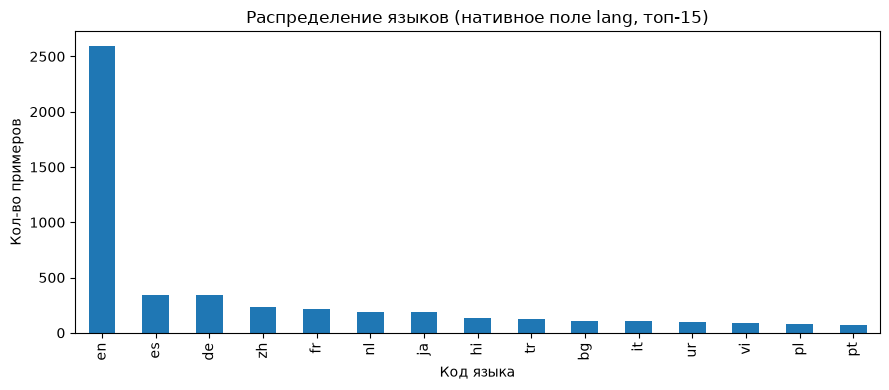

In [10]:
top_langs = native_counts.head(15)
plt.figure(figsize=(9, 4))
top_langs.plot(kind="bar")
plt.title("Распределение языков (нативное поле lang, топ-15)")
plt.ylabel("Кол-во примеров")
plt.xlabel("Код языка")
plt.tight_layout()
plt.show()

## 10. Гистограммы распределений

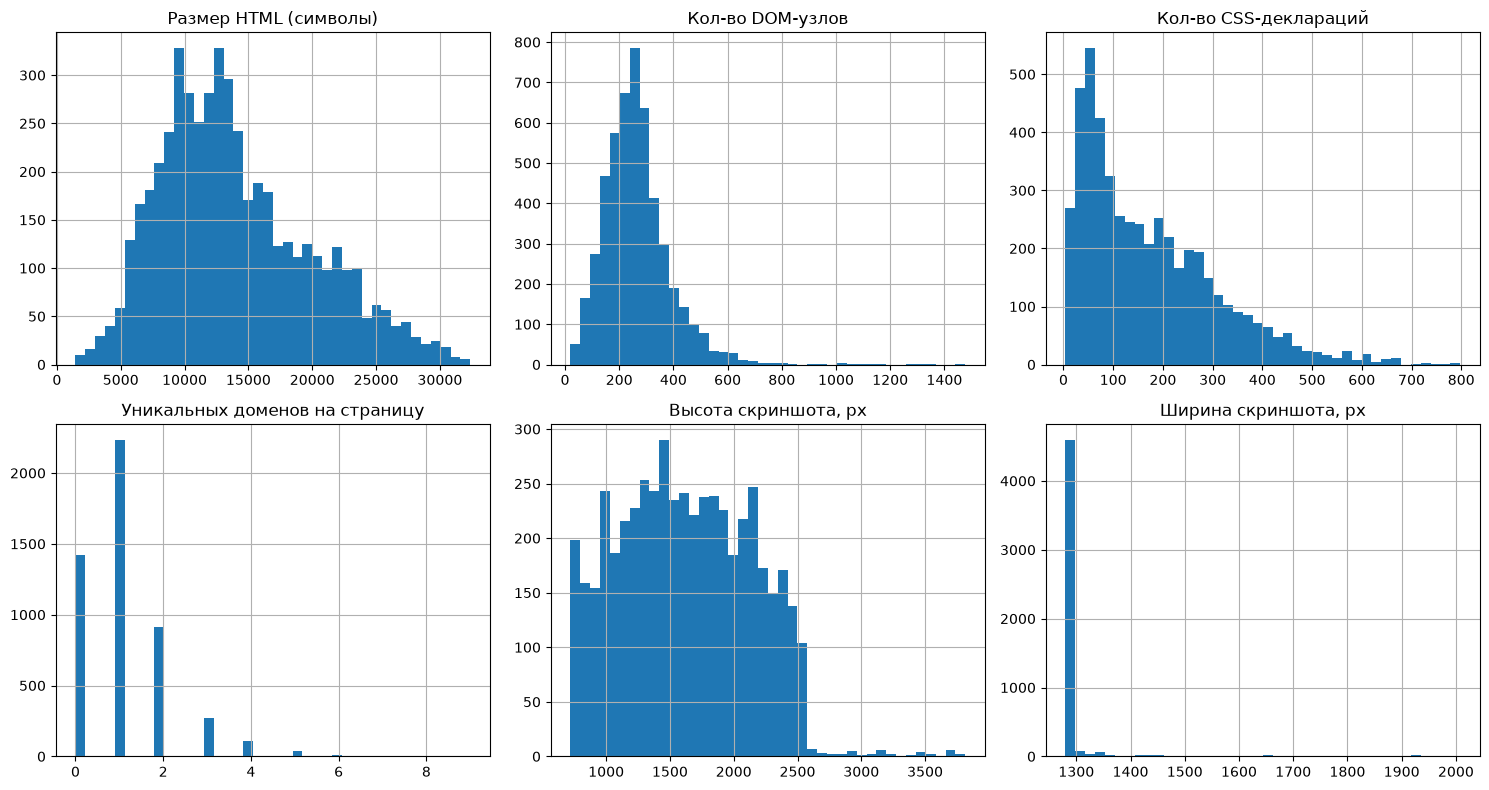

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ok["html_chars"].hist(ax=axes[0, 0], bins=40)
axes[0, 0].set_title("Размер HTML (символы)")

ok["dom_nodes"].hist(ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Кол-во DOM-узлов")

ok["css_decls"].hist(ax=axes[0, 2], bins=40)
axes[0, 2].set_title("Кол-во CSS-деклараций")

ok["n_domains"].hist(ax=axes[1, 0], bins=40)
axes[1, 0].set_title("Уникальных доменов на страницу")

ok["img_h"].hist(ax=axes[1, 1], bins=40)
axes[1, 1].set_title("Высота скриншота, px")

ok["img_w"].hist(ax=axes[1, 2], bins=40)
axes[1, 2].set_title("Ширина скриншота, px")

plt.tight_layout()
plt.show()

## 11. Итоговая сводка

Сопоставление с каждым пунктом `required_data.md`.

In [12]:
def fmt(x):
    return f"{x:,.1f}" if x is not None else "n/a"

w_mode = ok["img_w"].mode()
w_mode = int(w_mode.iloc[0]) if len(w_mode) else None

summary = pd.DataFrame([
    ("1. Количество примеров",                 f"{TOTAL_EXAMPLES:,}" if TOTAL_EXAMPLES else "n/a"),
    ("2. Количество языков (поле lang)",       f"{n_langs_native}  (langdetect: {n_langs_detect})"),
    ("3. Средний размер HTML (символы)",       fmt(ok["html_chars"].mean())),
    ("   Средний размер HTML (байт)",          fmt(ok["html_bytes"].mean())),
    ("4. Среднее кол-во DOM-узлов",            fmt(ok["dom_nodes"].mean())),
    ("5. Размер скриншота (W x H, px)",        f"{w_mode} x {fmt(ok['img_h'].mean())} (средняя высота)"),
    ("6. Среднее кол-во CSS правил",           fmt(ok["css_decls"].mean())),
    ("7. Среднее кол-во уникальных доменов",   fmt(ok["n_domains"].mean())),
], columns=["Метрика (required_data.md)", "Значение"])

print(f"Выборка для метрик 2-7: {len(ok):,} успешно распарсенных примеров "
      f"(из {len(df):,} загруженных)\n")
summary

Выборка для метрик 2-7: 5,000 успешно распарсенных примеров (из 5,000 загруженных)



,Метрика (required_data.md),Значение
0,1. Количество примеров,"2,562,069"
1,2. Количество языков (поле lang),19 (langdetect: 41)
2,3. Средний размер HTML (символы),"13,992.3"
3,Средний размер HTML (байт),"14,239.5"
4,4. Среднее кол-во DOM-узлов,265.0
5,"5. Размер скриншота (W x H, px)","1280 x 1,624.2 (средняя высота)"
6,6. Среднее кол-во CSS правил,173.0
7,7. Среднее кол-во уникальных доменов,1.1
